### Libraries.

In [ ]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.special import softmax
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import ShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

import torch
import xgboost as xgb

import sc_exp_design

sys.path.insert(0, "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/target_prediction_model")
from classification_utils import validate_classification_results


### Constants.

In [ ]:
USE_CLASS_WEIGHTS = True
USE_PCA = False


### Paths.

In [ ]:
ADATA_PATH = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/gdrive/ds_HID01_logicle_100k_UMAP_ann.h5ad"


### Reading annotated data.

In [ ]:
adata = sc.read_h5ad(ADATA_PATH)
adata


AnnData object with n_obs × n_vars = 100000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap'
    obsm: 'X_pca', 'X_umap'
    layers: 'positives', 'raw'
    

### Label Encoder for target.

In [ ]:
le_cell_type = LabelEncoder()
le_cell_type.fit(adata.obs["cell_type"].values)


LabelEncoder()

### Inspecting the distribution of the target variable.

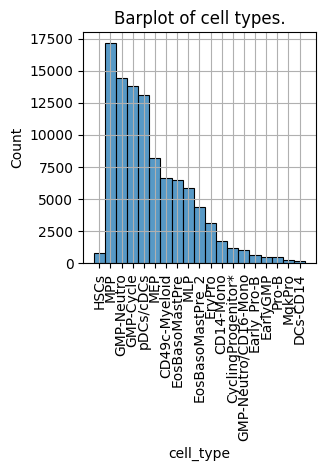

In [ ]:
plt.figure(figsize=(3, 3))
sns.histplot(adata.obs, x="cell_type")
plt.title("Barplot of cell types.")
plt.xticks(rotation=90)
plt.grid(True)


### Validation Split (Shuffle).

(70000,) (30000,)


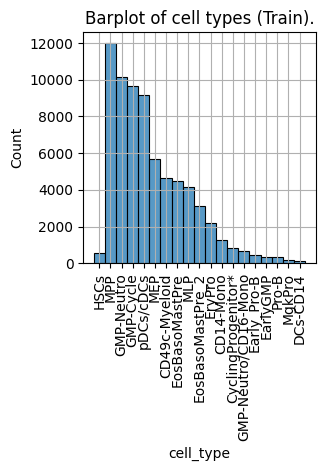

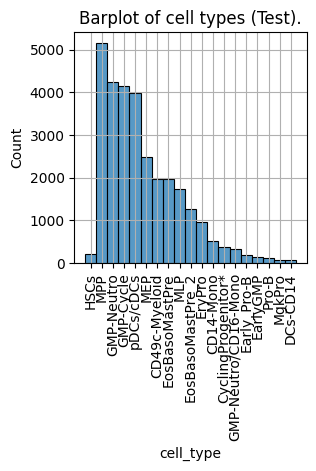

In [ ]:
K = 3
test_size = 0.3
skf = ShuffleSplit(n_splits=K, test_size=test_size)
splits = skf.split(np.zeros(len(adata)), adata.obs["cell_type"].values)
(train_index, test_index) = next(iter(splits))
print(train_index.shape, test_index.shape)

plt.figure(figsize=(3, 3))
sns.histplot(adata[train_index].obs, x="cell_type")
plt.title("Barplot of cell types (Train).")
plt.xticks(rotation=90)
plt.grid(True)

plt.figure(figsize=(3, 3))
sns.histplot(adata[test_index].obs, x="cell_type")
plt.title("Barplot of cell types (Test).")
plt.xticks(rotation=90)
plt.grid(True)


### Splitting adata.

In [ ]:
train_adata = adata[train_index]
val_adata = adata[test_index]
train_adata, val_adata


(View of AnnData object with n_obs × n_vars = 70000 × 21
     obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type'
     var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
     uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap'
     obsm: 'X_pca', 'X_umap'
     layers: 'positives

### Computing class weights.

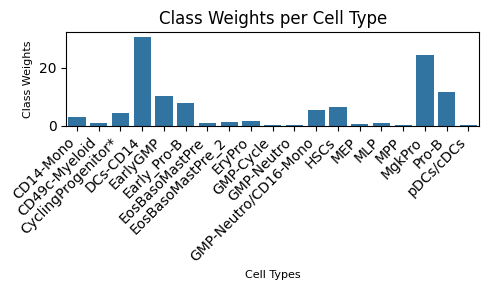

In [ ]:
values = train_adata.obs["cell_type"].values
classes = np.unique(values)
class_weights = torch.from_numpy(compute_class_weight("balanced", classes=np.unique(train_adata.obs["cell_type"].values), y=train_adata.obs["cell_type"].values)).float().to("cuda")
df = pd.DataFrame({"class_weights":class_weights.detach().cpu().numpy(), "cell_types":classes})

# Plot
plt.figure(figsize=(5,3))
sns.barplot(x="cell_types", y="class_weights", data=df)

# Beautify
plt.xticks(rotation=45, ha="right")
plt.xlabel("Cell Types", fontsize=8)
plt.ylabel("Class Weights", fontsize=8)
plt.title("Class Weights per Cell Type")
plt.tight_layout()
plt.show()



### Preparing data.

In [ ]:
BATCH_SIZE = 256
dm = sc_exp_design.data.DataManager(
    train_adata,
    sample_rep="X_pca" if USE_PCA else None,
    load_target_covariates=True,
    target_covariates={"cell_type":"label"}
)
train_data = dm.get_data(train_adata)
val_data = dm.get_data(val_adata)
train_data.state_data = train_data.state_data.toarray()
val_data.state_data = val_data.state_data.toarray()

train_dataloader = sc_exp_design.data.SequentialDataLoader(
    train_data,
    BATCH_SIZE,
)


### Initializing MLP target prediction network.

In [ ]:
mlp_target_prediction_model = sc_exp_design.networks.PerturbationApproximatePosterior(
    train_data.state_data.shape[1],
    freeze_grads=False,
    target_output_dims={"cell_type": adata.obs.cell_type.nunique()},
    noise_models={"cell_type": None},
    covariate_kwargs={
        "cell_type":{
            "hidden_dims": (256, 256),
            "activation_class": torch.nn.ReLU,
            "use_dropout": False,
            "use_batchnorm": False,
            "final_activation_class": torch.nn.Identity,
        }
    }
)
mlp_target_prediction_model = mlp_target_prediction_model.float()
mlp_target_prediction_model = mlp_target_prediction_model.to("cuda")

mlp_optimizer = torch.optim.Adam(mlp_target_prediction_model.parameters(), lr=1e-3, weight_decay=1e-3)


### Initializing Linear Classifier.

In [ ]:
lm_target_prediction_model = sc_exp_design.networks.PerturbationApproximatePosterior(
    train_data.state_data.shape[1],
    freeze_grads=False,
    target_output_dims={"cell_type": adata.obs.cell_type.nunique()},
    noise_models={"cell_type": None},
    covariate_kwargs={
        "cell_type":{
            "hidden_dims": (),
            "activation_class": torch.nn.ReLU,
            "use_dropout": False,
            "use_batchnorm": False,
            "final_activation_class": torch.nn.Identity,
        }
    }
)
lm_target_prediction_model = lm_target_prediction_model.float()
lm_target_prediction_model = lm_target_prediction_model.to("cuda")

lm_optimizer = torch.optim.Adam(lm_target_prediction_model.parameters(), lr=1e-3)


### Fitting the MLP model.

Loss: 0.0529: 100%|██████████| 100000/100000 [02:25<00:00, 685.15it/s]


(<Figure size 300x300 with 1 Axes>, <Axes: title={'center': 'loss'}>)

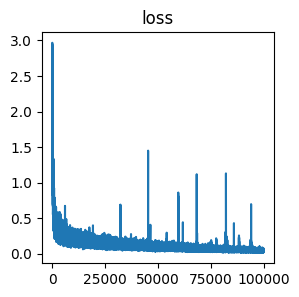

In [13]:
NUM_TRAINING_STEPS = 100_000

mlp_trainer = sc_exp_design.training.TargetPredictionTrainer(
    mlp_target_prediction_model,
    mlp_optimizer,
    loss_fn_kwargs={"weight":class_weights}
)
mlp_trainer.fit(
    NUM_TRAINING_STEPS,
    train_dataloader,
)
mlp_trainer.plot_training_logs()


### Fitting the linear Model.

Loss: 0.5105: 100%|██████████| 100000/100000 [01:42<00:00, 971.18it/s]


(<Figure size 300x300 with 1 Axes>, <Axes: title={'center': 'loss'}>)

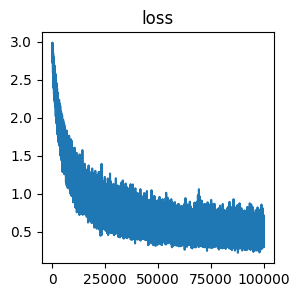

In [14]:
lm_trainer = sc_exp_design.training.TargetPredictionTrainer(
    lm_target_prediction_model,
    lm_optimizer,
    loss_fn_kwargs={"weight":class_weights}
)
lm_trainer.fit(
    NUM_TRAINING_STEPS,
    train_dataloader,
)
lm_trainer.plot_training_logs()


### Visualize weights of LM.

<Axes: title={'center': 'Heatmaps of LM weights.'}>

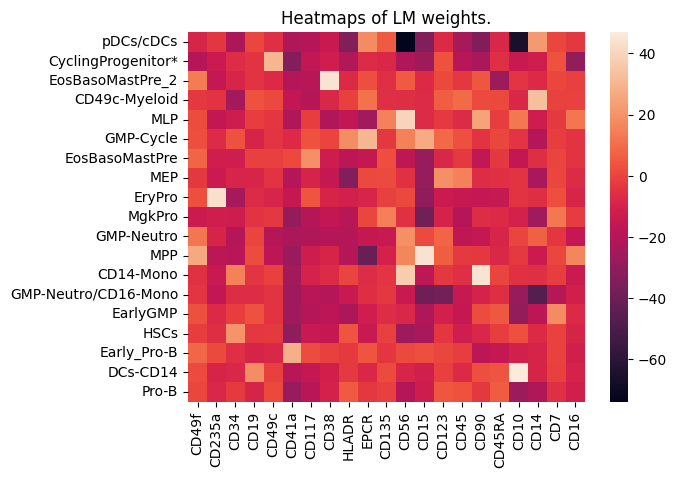

In [15]:
W = next(iter(lm_target_prediction_model.parameters())).data.detach().cpu().numpy()
plt.title("Heatmaps of LM weights.")
sns.heatmap(W, yticklabels=adata.obs.cell_type.unique(), xticklabels=adata.var_names if not USE_PCA else [f"PC{idx}" for idx in range(W.shape[1])])


### Fitting XGBoost Classifier.

In [16]:
X = train_data.state_data
Y = train_data.target_data["cell_type"]
xgb_classifier = xgb.XGBClassifier(
    tree_method="hist",
    object="multi:softprob",
    n_estimators=128,
    n_jobs=16,
    max_depth=8,
    multi_strategy="one_output_per_tree",
    subsample=0.6,
)
xgb_classifier.fit(X, Y)


/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [12:16:30] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "object" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy='one_output_per_tree',
              n_estimators=128, n_jobs=16, num_parallel_tree=None, ...)

### Fitting Logistic Regressor from sklearn.

In [27]:
lm = LogisticRegression(max_iter=1_000)
lm.fit(X, Y)


LogisticRegression(max_iter=1000)

### Visualize Weights for LM.

<Axes: title={'center': 'Heatmaps of LM weights.'}>

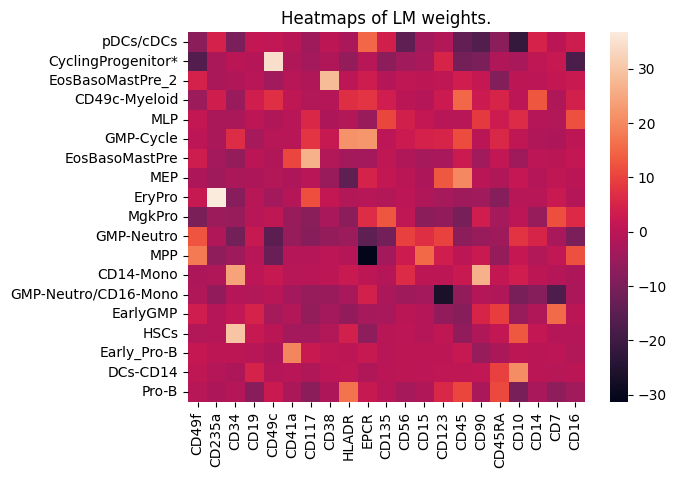

In [30]:
W = lm.coef_  # shape: (n_classes, n_features)
plt.title("Heatmaps of LM weights.")
sns.heatmap(W, yticklabels=adata.obs.cell_type.unique(), xticklabels=adata.var_names if not USE_PCA else [f"PC{idx}" for idx in range(W.shape[1])])


### Predicting on train data with MLP and computing classification metrics.

Accuracy: 0.9624142857142857
Precision (weighted): 0.963691772811706
Recall (weighted): 0.9624142857142857
F1-score (weighted): 0.9622022493236891

Full classification report:

                      precision    recall  f1-score   support

           CD14-Mono       0.98      1.00      0.99      1239
       CD49c-Myeloid       0.92      1.00      0.96      4648
  CyclingProgenitor*       1.00      1.00      1.00       828
            DCs-CD14       1.00      1.00      1.00       120
            EarlyGMP       0.99      1.00      1.00       359
         Early_Pro-B       1.00      1.00      1.00       462
      EosBasoMastPre       0.98      1.00      0.99      4493
    EosBasoMastPre_2       0.93      1.00      0.96      3132
              EryPro       1.00      1.00      1.00      2191
           GMP-Cycle       0.98      0.88      0.93      9675
          GMP-Neutro       0.99      0.92      0.95     10168
GMP-Neutro/CD16-Mono       1.00      1.00      1.00       687
                

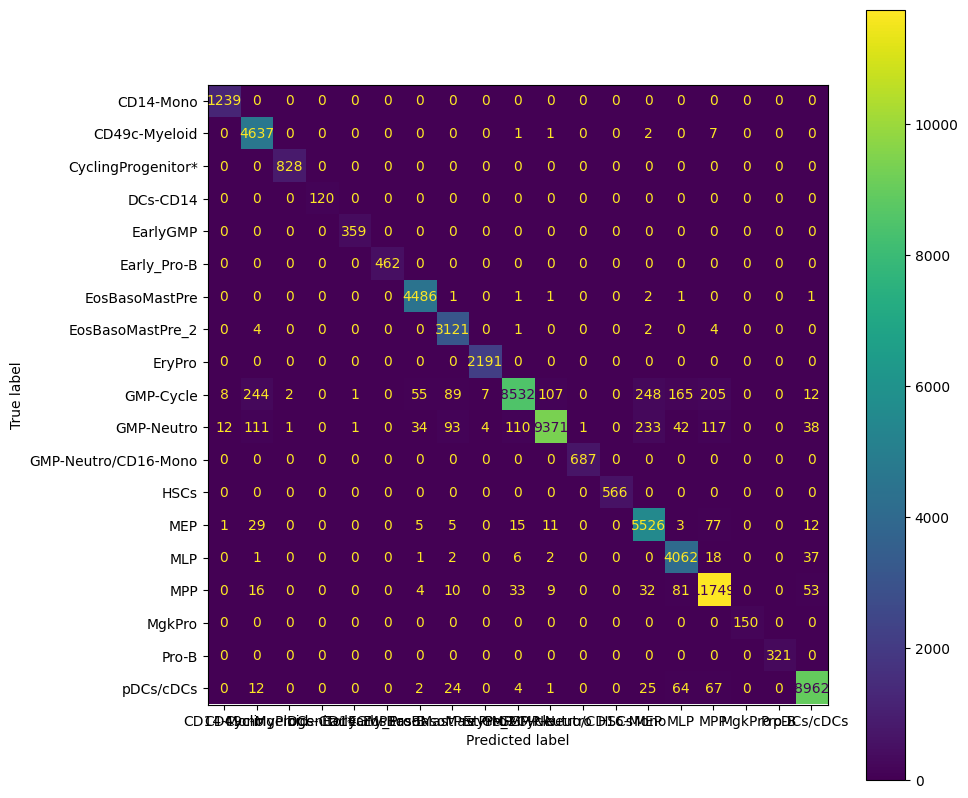

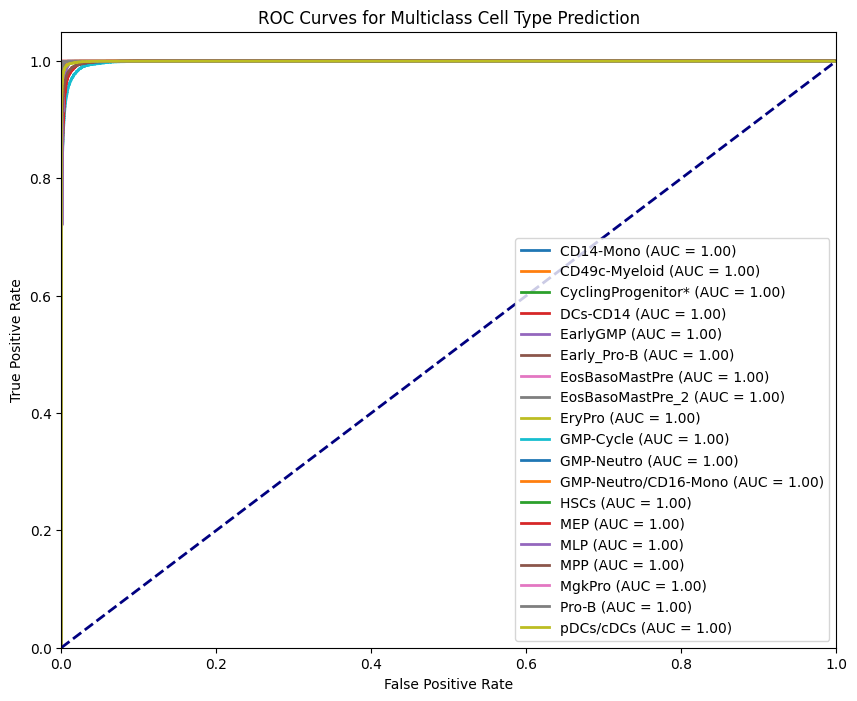

Macro-average ROC AUC: 1.000
Micro-average ROC AUC: 1.000


In [37]:
mlp_train_cell_type_logits = mlp_target_prediction_model(
    torch.from_numpy(train_data.state_data).float().to("cuda")
)["cell_type"].detach().cpu().numpy()
mlp_train_cell_type_probs = softmax(mlp_train_cell_type_logits, axis=1)

results = validate_classification_results(
    train_adata,
    mlp_train_cell_type_probs,
    le_cell_type,
)


### Predicting on validation data with MLP and computing classification metrics.

Accuracy: 0.8862333333333333
Precision (weighted): 0.8884038390120809
Recall (weighted): 0.8862333333333333
F1-score (weighted): 0.8862236811675489

Full classification report:

                      precision    recall  f1-score   support

           CD14-Mono       0.81      0.85      0.83       527
       CD49c-Myeloid       0.83      0.92      0.87      1981
  CyclingProgenitor*       0.98      0.96      0.97       372
            DCs-CD14       0.90      0.86      0.88        65
            EarlyGMP       0.76      0.79      0.78       146
         Early_Pro-B       0.92      0.89      0.90       196
      EosBasoMastPre       0.90      0.94      0.92      1981
    EosBasoMastPre_2       0.80      0.88      0.84      1271
              EryPro       0.95      0.95      0.95       972
           GMP-Cycle       0.91      0.80      0.85      4147
          GMP-Neutro       0.93      0.86      0.89      4246
GMP-Neutro/CD16-Mono       0.96      0.92      0.94       328
               

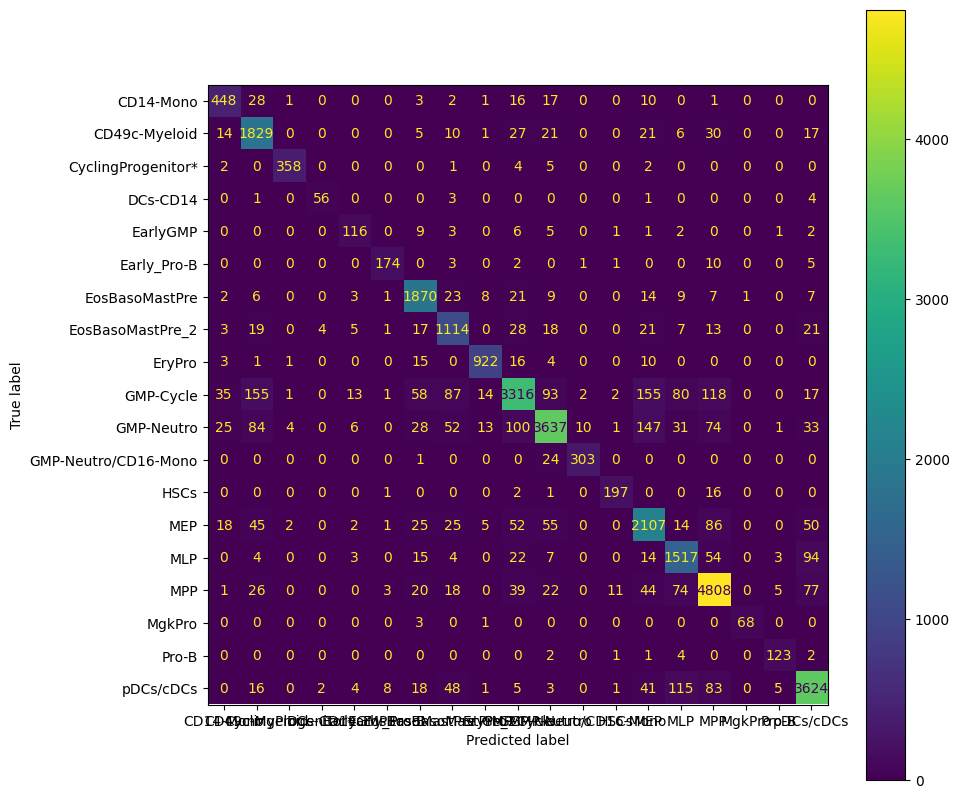

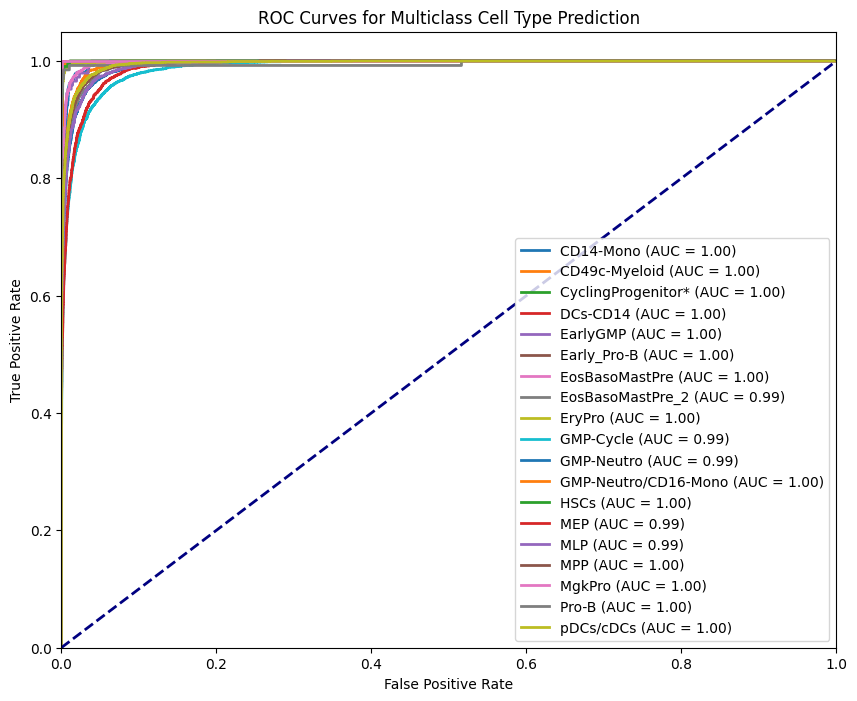

Macro-average ROC AUC: 0.997
Micro-average ROC AUC: 0.997


In [38]:
mlp_val_cell_type_logits = mlp_target_prediction_model(
    torch.from_numpy(val_data.state_data).float().to("cuda")
)["cell_type"].detach().cpu().numpy()
mlp_val_cell_type_probs = softmax(mlp_val_cell_type_logits, axis=1)

results = validate_classification_results(
    val_adata,
    mlp_val_cell_type_probs,
    le_cell_type,
)



### Predicting on train data with LM and computing classification metrics.


Accuracy: 0.7948
Precision (weighted): 0.8227716790366388
Recall (weighted): 0.7948
F1-score (weighted): 0.8004177229133081

Full classification report:

                      precision    recall  f1-score   support

           CD14-Mono       0.48      0.88      0.62      1239
       CD49c-Myeloid       0.81      0.85      0.83      4648
  CyclingProgenitor*       0.87      0.98      0.92       828
            DCs-CD14       0.35      0.97      0.51       120
            EarlyGMP       0.32      0.92      0.47       359
         Early_Pro-B       0.46      0.92      0.61       462
      EosBasoMastPre       0.88      0.86      0.87      4493
    EosBasoMastPre_2       0.72      0.88      0.79      3132
              EryPro       0.91      0.95      0.93      2191
           GMP-Cycle       0.86      0.68      0.76      9675
          GMP-Neutro       0.85      0.74      0.79     10168
GMP-Neutro/CD16-Mono       0.58      0.91      0.71       687
                HSCs       0.51      0.

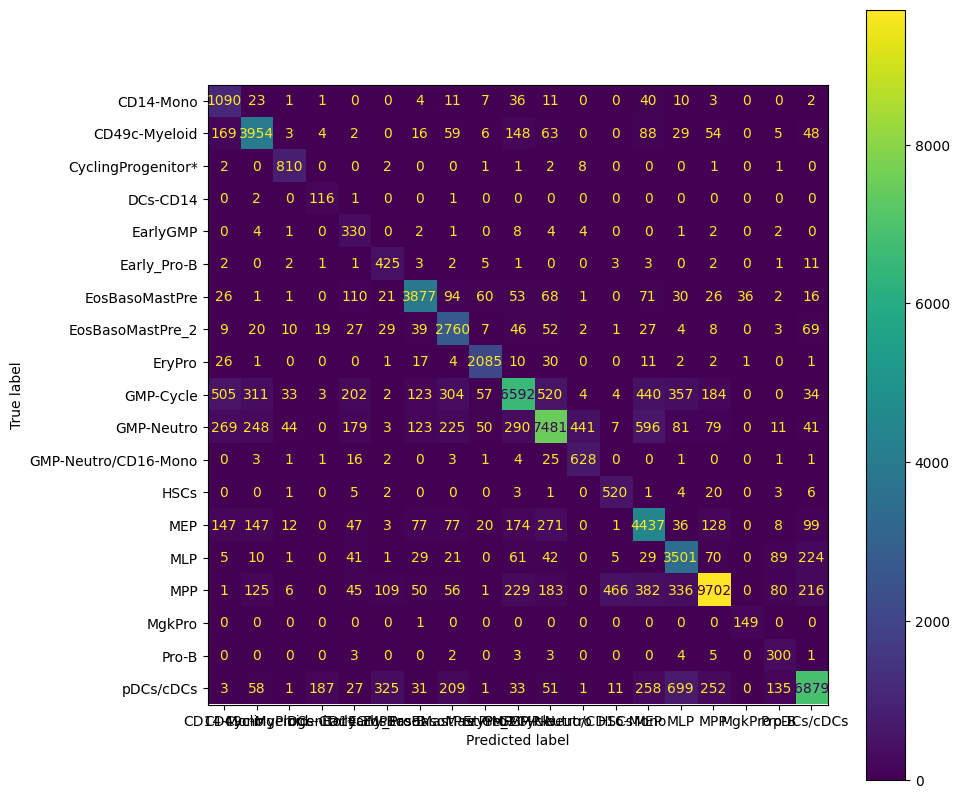

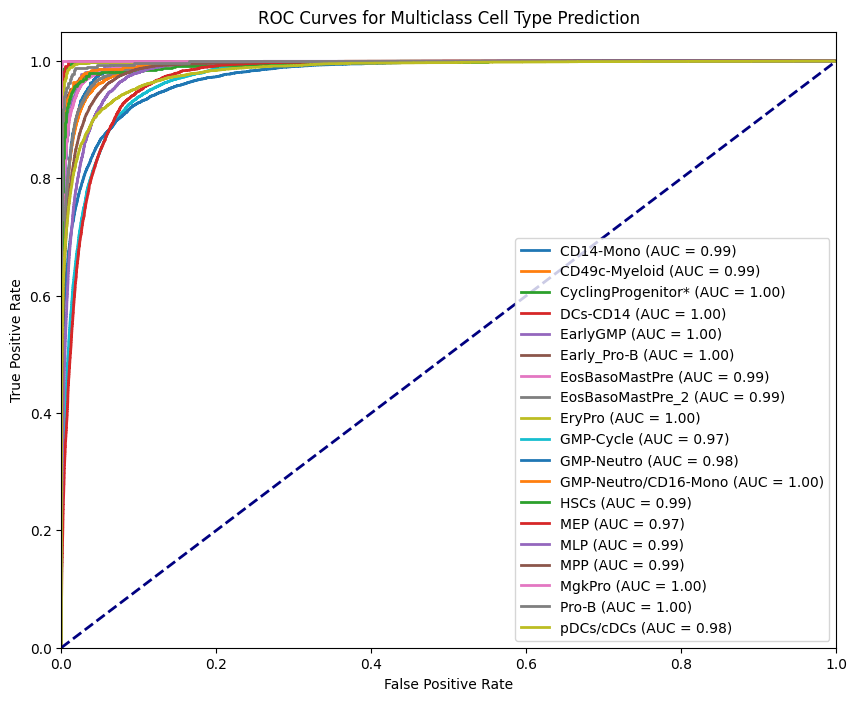

Macro-average ROC AUC: 0.991
Micro-average ROC AUC: 0.990


In [39]:
lm_train_cell_type_logits = lm_target_prediction_model(
    torch.from_numpy(train_data.state_data).float().to("cuda")
)["cell_type"].detach().cpu().numpy()
lm_train_cell_type_probs = softmax(lm_train_cell_type_logits, axis=1)

results = validate_classification_results(
    train_adata,
    lm_train_cell_type_probs,
    le_cell_type,
)


### Predicting on val data with LM and computing classification metrics.

Accuracy: 0.7905
Precision (weighted): 0.8214695134241167
Recall (weighted): 0.7905
F1-score (weighted): 0.796578935753653

Full classification report:

                      precision    recall  f1-score   support

           CD14-Mono       0.47      0.91      0.62       527
       CD49c-Myeloid       0.80      0.85      0.82      1981
  CyclingProgenitor*       0.86      0.96      0.91       372
            DCs-CD14       0.35      0.85      0.49        65
            EarlyGMP       0.30      0.86      0.44       146
         Early_Pro-B       0.44      0.94      0.60       196
      EosBasoMastPre       0.87      0.87      0.87      1981
    EosBasoMastPre_2       0.69      0.87      0.77      1271
              EryPro       0.91      0.95      0.93       972
           GMP-Cycle       0.87      0.67      0.76      4147
          GMP-Neutro       0.86      0.73      0.79      4246
GMP-Neutro/CD16-Mono       0.60      0.91      0.72       328
                HSCs       0.44      0.9

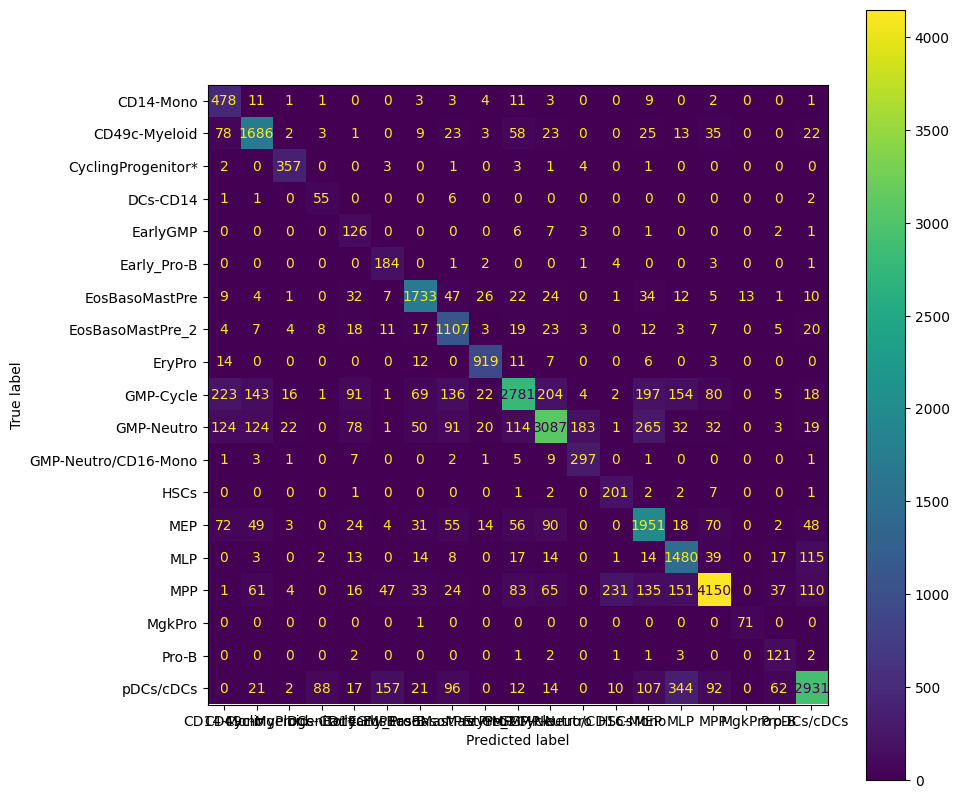

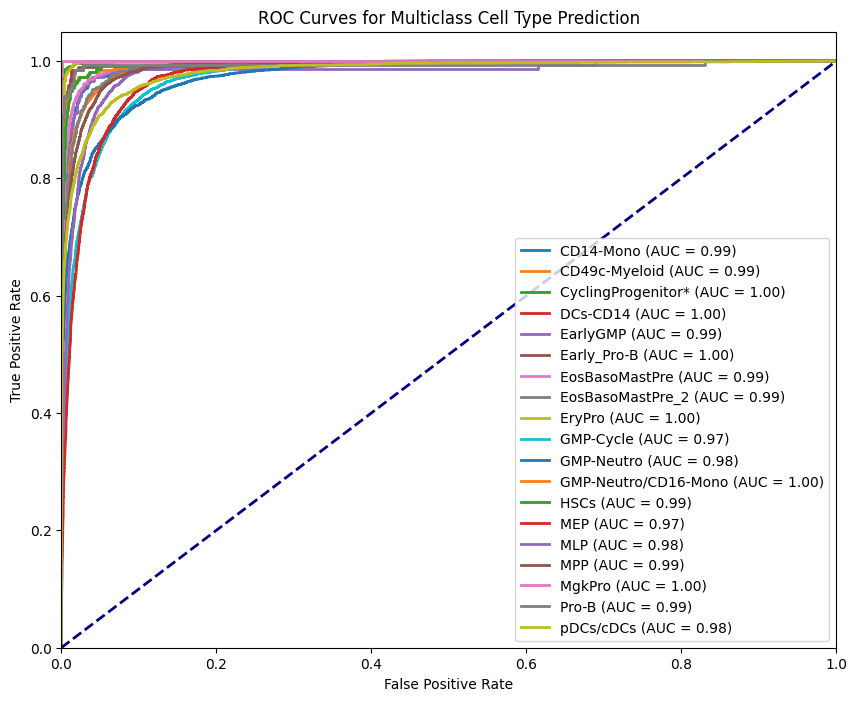

Macro-average ROC AUC: 0.990
Micro-average ROC AUC: 0.989


In [40]:
lm_val_cell_type_logits = lm_target_prediction_model(
    torch.from_numpy(val_data.state_data).float().to("cuda")
)["cell_type"].detach().cpu().numpy()
lm_val_cell_type_probs = softmax(lm_val_cell_type_logits, axis=1)

results = validate_classification_results(
    val_adata,
    lm_val_cell_type_probs,
    le_cell_type,
)


### Predicting on train data with XGBoost and computing classification metrics.

Accuracy: 1.0
Precision (weighted): 1.0
Recall (weighted): 1.0
F1-score (weighted): 1.0

Full classification report:

                      precision    recall  f1-score   support

           CD14-Mono       1.00      1.00      1.00      1239
       CD49c-Myeloid       1.00      1.00      1.00      4648
  CyclingProgenitor*       1.00      1.00      1.00       828
            DCs-CD14       1.00      1.00      1.00       120
            EarlyGMP       1.00      1.00      1.00       359
         Early_Pro-B       1.00      1.00      1.00       462
      EosBasoMastPre       1.00      1.00      1.00      4493
    EosBasoMastPre_2       1.00      1.00      1.00      3132
              EryPro       1.00      1.00      1.00      2191
           GMP-Cycle       1.00      1.00      1.00      9675
          GMP-Neutro       1.00      1.00      1.00     10168
GMP-Neutro/CD16-Mono       1.00      1.00      1.00       687
                HSCs       1.00      1.00      1.00       566
             

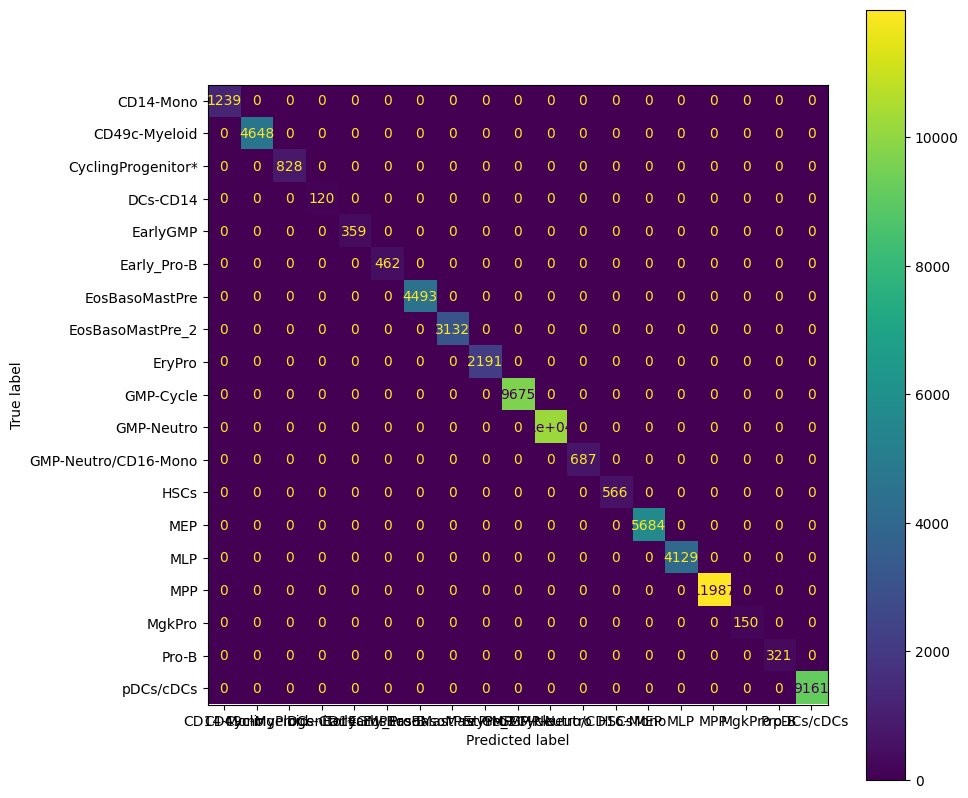

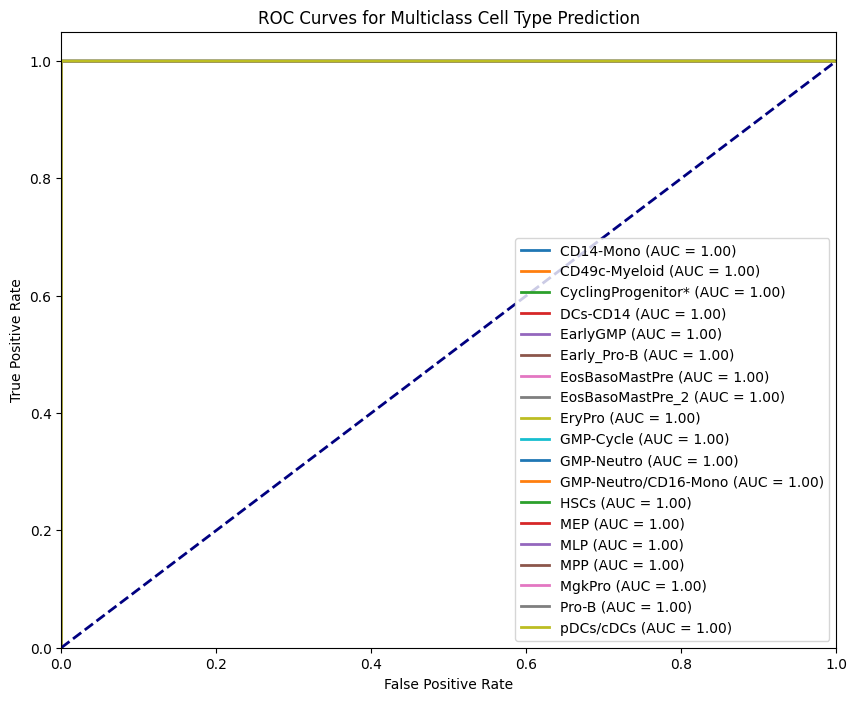

Macro-average ROC AUC: 1.000
Micro-average ROC AUC: 1.000


In [41]:
xgb_train_cell_type_probs = xgb_classifier.predict_proba(train_data.state_data, )
results = validate_classification_results(
    train_adata,
    xgb_train_cell_type_probs,
    le_cell_type,
)


### Predicting on val data with XGBoost and computing classification metrics.


Accuracy: 0.8831666666666667
Precision (weighted): 0.8827928858031526
Recall (weighted): 0.8831666666666667
F1-score (weighted): 0.8827328394600713

Full classification report:

                      precision    recall  f1-score   support

           CD14-Mono       0.85      0.81      0.83       527
       CD49c-Myeloid       0.89      0.86      0.87      1981
  CyclingProgenitor*       0.96      0.95      0.96       372
            DCs-CD14       0.78      0.77      0.78        65
            EarlyGMP       0.82      0.56      0.67       146
         Early_Pro-B       0.81      0.81      0.81       196
      EosBasoMastPre       0.90      0.91      0.91      1981
    EosBasoMastPre_2       0.83      0.83      0.83      1271
              EryPro       0.95      0.94      0.94       972
           GMP-Cycle       0.86      0.87      0.86      4147
          GMP-Neutro       0.89      0.90      0.90      4246
GMP-Neutro/CD16-Mono       0.94      0.89      0.92       328
               

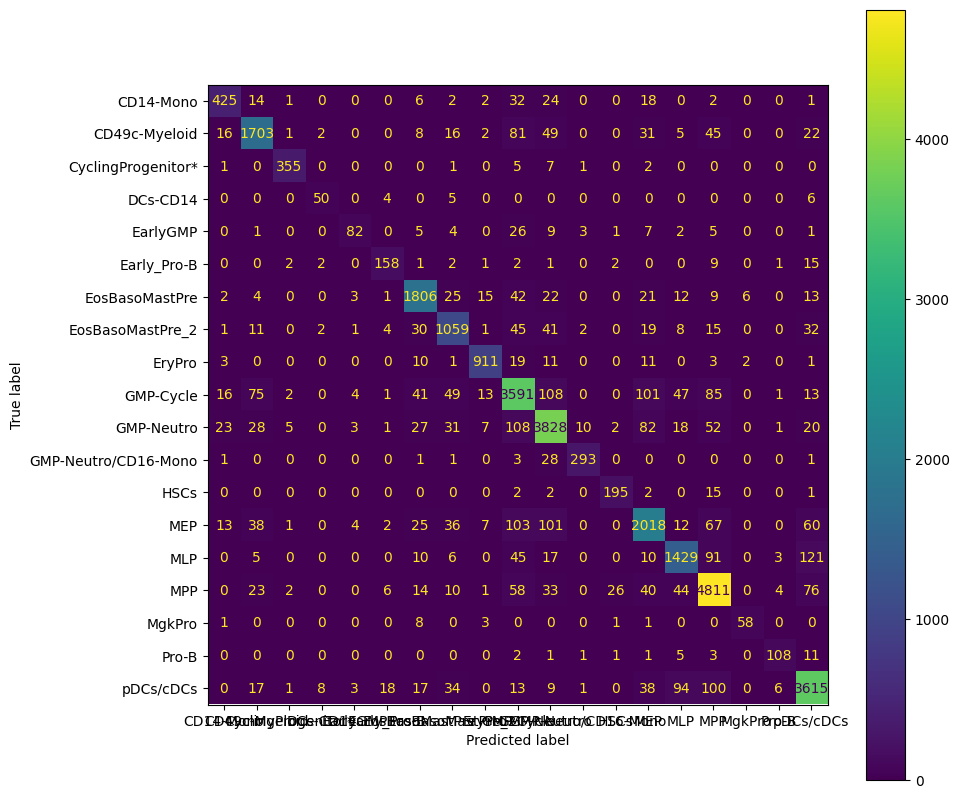

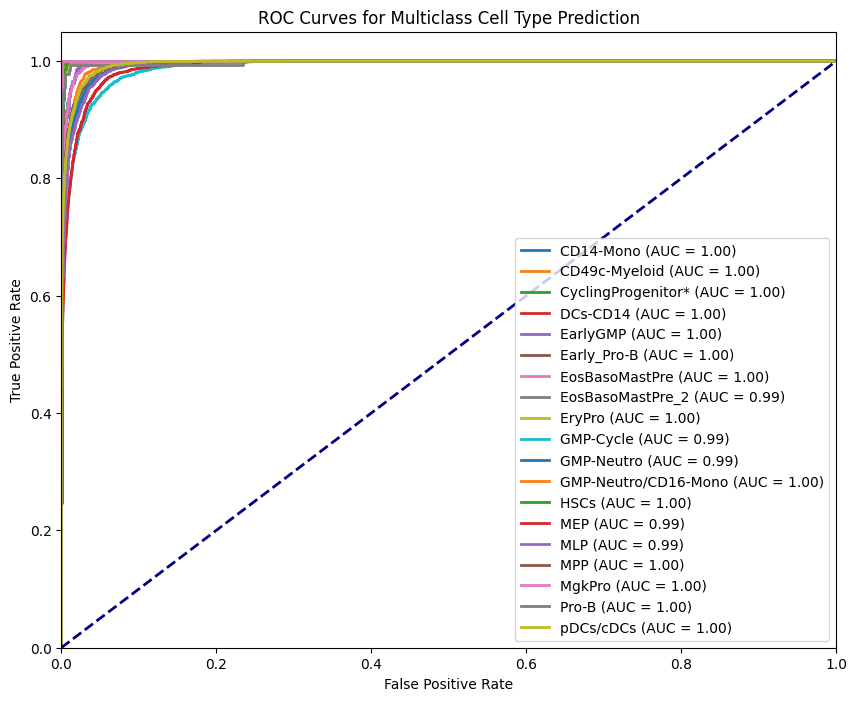

Macro-average ROC AUC: 0.997
Micro-average ROC AUC: 0.997


In [42]:
xgb_val_cell_type_probs = xgb_classifier.predict_proba(val_data.state_data, )
results = validate_classification_results(
    val_adata,
    xgb_val_cell_type_probs,
    le_cell_type,
)


### Predicting on Train Data with LM from sklearn.

Accuracy: 0.8056714285714286
Precision (weighted): 0.8123618708965564
Recall (weighted): 0.8056714285714286
F1-score (weighted): 0.7983868142759182

Full classification report:

                      precision    recall  f1-score   support

           CD14-Mono       0.88      0.22      0.35      1239
       CD49c-Myeloid       0.85      0.79      0.82      4648
  CyclingProgenitor*       0.99      0.73      0.84       828
            DCs-CD14       0.89      0.21      0.34       120
            EarlyGMP       0.72      0.08      0.14       359
         Early_Pro-B       0.81      0.48      0.60       462
      EosBasoMastPre       0.89      0.85      0.87      4493
    EosBasoMastPre_2       0.82      0.74      0.78      3132
              EryPro       0.96      0.84      0.90      2191
           GMP-Cycle       0.72      0.84      0.77      9675
          GMP-Neutro       0.75      0.86      0.80     10168
GMP-Neutro/CD16-Mono       0.89      0.48      0.63       687
               

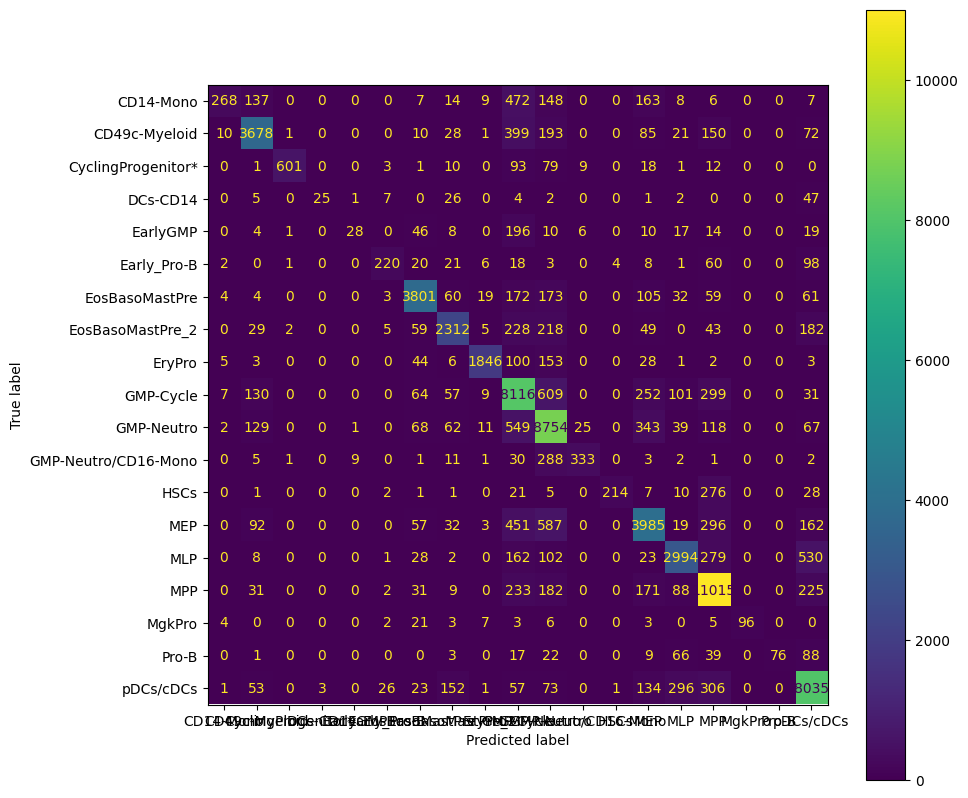

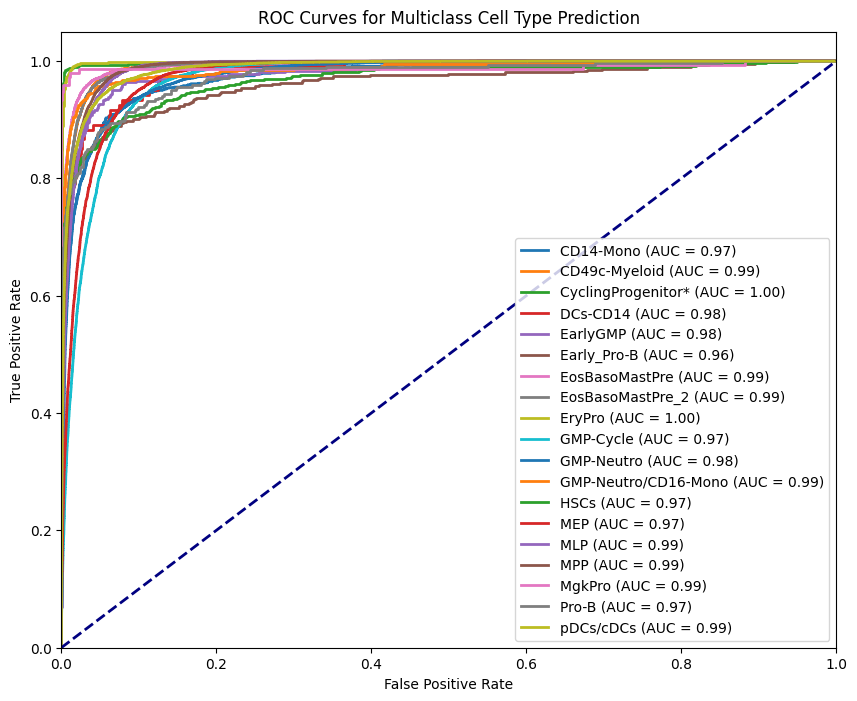

Macro-average ROC AUC: 0.983
Micro-average ROC AUC: 0.990


In [43]:
lm_val_cell_type_probs = lm.predict_proba(X, )
results = validate_classification_results(
    train_adata,
    lm_val_cell_type_probs,
    le_cell_type,
)


### Predicting on Validation Data with LM from sklearn.

Accuracy: 0.8031666666666667
Precision (weighted): 0.8080505622310775
Recall (weighted): 0.8031666666666667
F1-score (weighted): 0.7960357104515647

Full classification report:

                      precision    recall  f1-score   support

           CD14-Mono       0.80      0.24      0.38       527
       CD49c-Myeloid       0.85      0.79      0.82      1981
  CyclingProgenitor*       1.00      0.72      0.84       372
            DCs-CD14       0.93      0.22      0.35        65
            EarlyGMP       0.62      0.05      0.10       146
         Early_Pro-B       0.76      0.48      0.59       196
      EosBasoMastPre       0.88      0.84      0.86      1981
    EosBasoMastPre_2       0.80      0.72      0.76      1271
              EryPro       0.96      0.81      0.88       972
           GMP-Cycle       0.72      0.83      0.77      4147
          GMP-Neutro       0.75      0.86      0.80      4246
GMP-Neutro/CD16-Mono       0.88      0.48      0.63       328
               

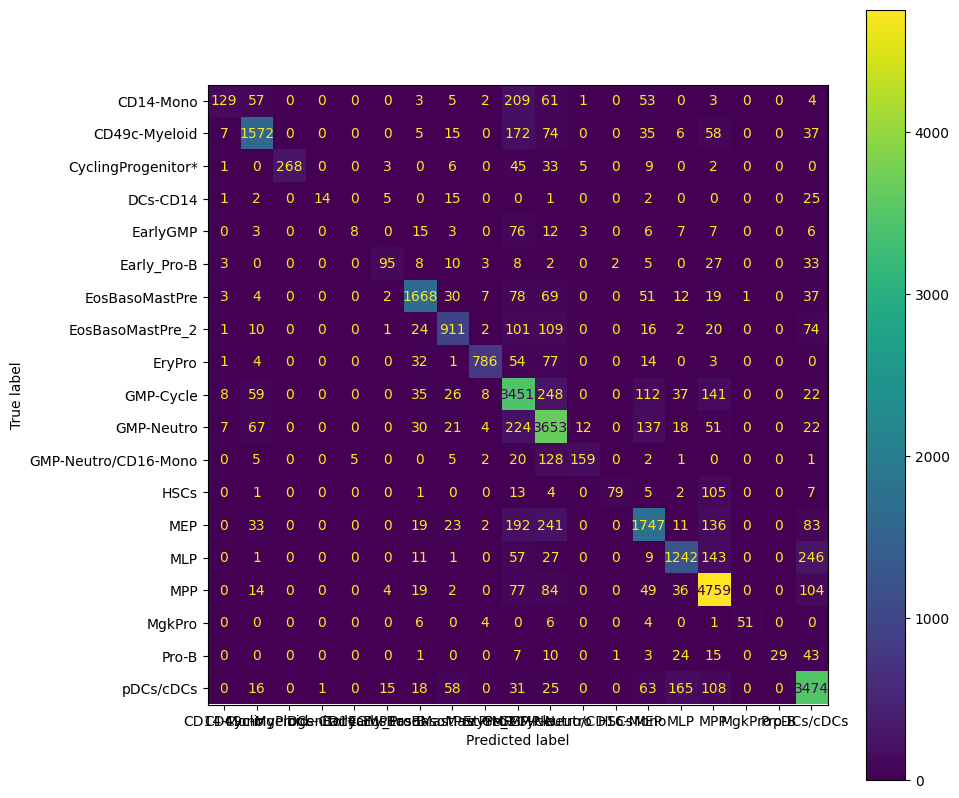

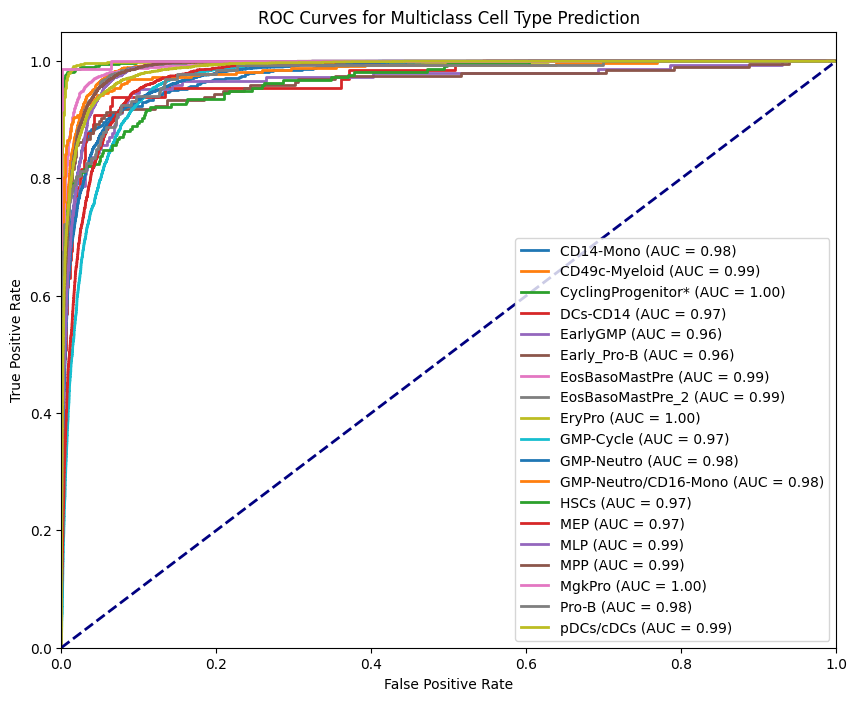

Macro-average ROC AUC: 0.982
Micro-average ROC AUC: 0.990


In [44]:
lm_val_cell_type_probs = lm.predict_proba(val_data.state_data, )
results = validate_classification_results(
    val_adata,
    lm_val_cell_type_probs,
    le_cell_type,
)
